In [1]:
# cleanup and fix isogeometric plate case
# first let's plot the basis functions from _plate.py
import numpy as np

# 1) make the open knot vector
nxe, p = 4, 1
# nxe, p = 4, 1
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
print(f"{knots=}")
n_ctrl = nxe + p # number of control ponts

# 2) find span to determine where in vector to do interpolations
def find_span(n_ctrl, degree, u, U):
    # Cox-de Boor span search (n_ctrl = number of control points)
    if u >= U[-1] - 1e-12:
        return n_ctrl - 1
    low = degree
    high = len(U)-degree-1
    mid = (low+high)//2
    while True:
        if u < U[mid]:
            high = mid
        elif u >= U[mid+1]:
            low = mid
        else:
            return mid
        mid = (low+high)//2

# get basis functions

def basis_functions_and_derivatives(span, u, degree, U, n_deriv=1):
    # Compute nonzero basis functions and first derivatives using Cox-de Boor + derivative formula
    # Returns arrays N[0:degree] and dN[0:degree]
    left = np.zeros(degree+1)
    right = np.zeros(degree+1)
    ndu = np.zeros((degree+1, degree+1))
    ndu[0,0] = 1.0
    for j in range(1, degree+1):
        left[j] = u - U[span+1-j]
        right[j] = U[span+j] - u
        saved = 0.0
        for r in range(j):
            ndu[j,r] = right[r+1] + left[j-r]
            temp = ndu[r,j-1]/ndu[j,r]
            ndu[r,j] = saved + right[r+1]*temp
            saved = left[j-r]*temp
        ndu[j,j] = saved
    N = ndu[:,degree].copy()
    # derivatives
    ders = np.zeros((n_deriv+1, degree+1))
    a = np.zeros((2, degree+1))
    # compute a triangular table of derivatives
    for r in range(degree+1):
        s1 = 0; s2 = 1
        a[0,0] = 1.0
        for k in range(1, n_deriv+1):
            d = 0.0
            rk = r - k
            pk = degree - k
            if r >= k:
                a[s2,0] = a[s1,0]/ndu[pk+1,rk]
                d = a[s2,0]*ndu[rk,pk]
            j1 = 1 if rk >= -1 else -rk
            j2 = k-1 if r-1 <= pk else degree - r
            for j in range(j1, j2+1):
                a[s2,j] = (a[s1,j] - a[s1,j-1]) / ndu[pk+1, rk+j]
                d += a[s2,j]*ndu[rk+j, pk]
            if r <= pk:
                a[s2,k] = -a[s1,k-1]/ndu[pk+1, r]
                d += a[s2,k]*ndu[r, pk]
            ders[k,r] = d
            s1, s2 = s2, s1
    # Multiply by correct factors
    for k in range(1, n_deriv+1):
        for j in range(degree+1):
            ders[k,j] *= degree
    return N, ders[1]

knots=[0.0, 0.0, 0.25, 0.5, 0.75, 1.0, 1.0]


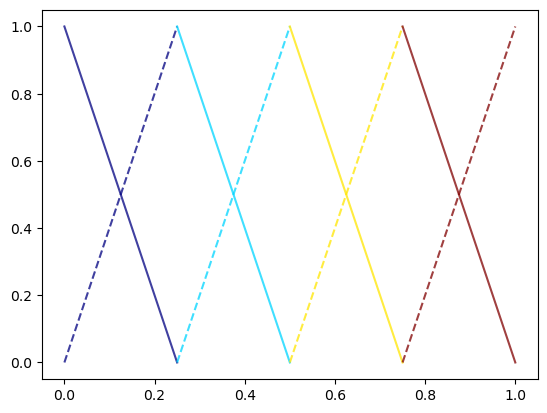

In [2]:
# now plot each separate basis function in the span?
import matplotlib.pyplot as plt

ielem = 0
colors = plt.cm.jet(np.linspace(0.0, 1.0, nxe))
linestyles = ['-', '--', '-.']

for i in range(len(knots)-1):
    knot1 = knots[i]; knot2 = knots[i+1]
    dknot = knot2 - knot1
    if abs(dknot) > 1e-12:
        uvec = np.linspace(knot1, knot2, 20)
        span = find_span(n_ctrl, p, np.mean(uvec), knots)  # gets starting index?
        Nvals = np.zeros((p+1, uvec.shape[0]))
        for ii, _u in enumerate(uvec):
            N, deriv = basis_functions_and_derivatives(span, _u, p, knots, n_deriv=1)
            Nvals[:,ii] = N[:]

        for iN in range(p+1):
            rand_scale = 0.0
            # rand_scale = 0.05
            plt.plot(uvec, Nvals[iN,:] + np.random.rand(1)*rand_scale, linestyle=linestyles[iN], color=colors[ielem], alpha=0.75)
        
        ielem += 1
plt.show()
